SOCIAL MEDIA SENTIMENT ANALYSIS PROJECT

IMPORTING LIBRARIES

In [2]:
!pip install vaderSentiment
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.0 MB/s eta 0:00:00


DATA CLEANING AND PREPROCCESING

In [18]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))
negation_words = {'not', 'no', 'never'}
stop_words = stop_words - negation_words
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
def preprocess_text(text):
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]
    return " ".join(tokens)
data['cleaned_text'] = data['Text'].apply(preprocess_text)
data = data[data['cleaned_text'].str.strip() != ""]
data[['Text', 'cleaned_text']].head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Text,cleaned_text
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park
1,Traffic was terrible this morning. ...,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight


DATA EXPLORATION

Dataset Shape: (732, 18)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
 15  clean_text    732 non-null    object 
 16  sentiment     732 non-null    object 
 17  cleaned_text  732 non-null    obj

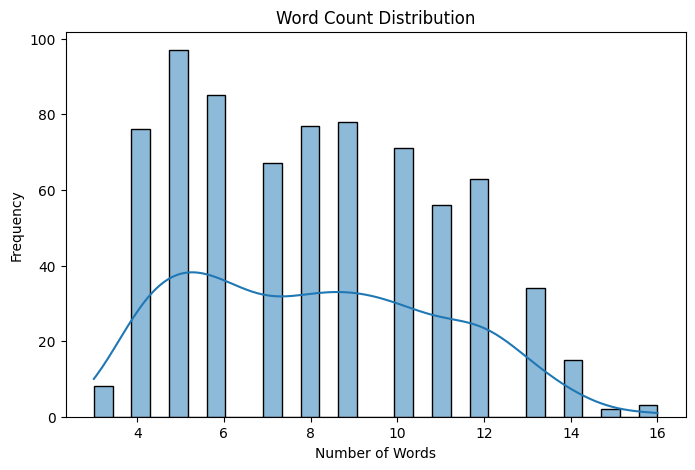

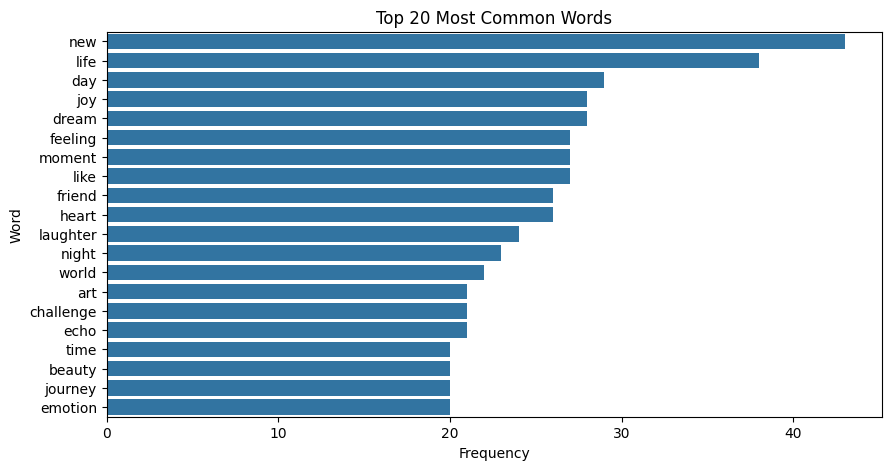


Sample Cleaned Text:
142                 empowerment mentoring guiding others
697    facing rejection dream college disheartened de...
391    immersed enchanting melody street musician violin
604    exploring world digital art never late discove...
540    celebrating historic victory world cup nation ...
Name: cleaned_text, dtype: object


In [19]:
print("Dataset Shape:", data.shape)
print("\nDataset Info:")
data.info()
print("\nMissing Values:")
print(data.isnull().sum())
print("\nDuplicate Rows:", data.duplicated().sum())
data['text_length'] = data['cleaned_text'].apply(len)
data['word_count'] = data['cleaned_text'].apply(lambda x: len(x.split()))
print("\nText Length Statistics:")
print(data[['text_length', 'word_count']].describe())
plt.figure(figsize=(8,5))
sns.histplot(data['word_count'], bins=30, kde=True)
plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()
from collections import Counter
all_words = " ".join(data['cleaned_text']).split()
common_words = Counter(all_words).most_common(20)
common_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
plt.figure(figsize=(10,5))
sns.barplot(x='Frequency', y='Word', data=common_df)
plt.title("Top 20 Most Common Words")
plt.show()
print("\nSample Cleaned Text:")
print(data['cleaned_text'].sample(5))


DATA MODELING(TF-IDF + LOGISTIC REGRESSION)

Accuracy: 0.673469387755102

Classification Report:

              precision    recall  f1-score   support

    Negative       0.78      0.19      0.30        37
     Neutral       0.00      0.00      0.00        16
    Positive       0.67      0.98      0.79        94

    accuracy                           0.67       147
   macro avg       0.48      0.39      0.37       147
weighted avg       0.62      0.67      0.58       147



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


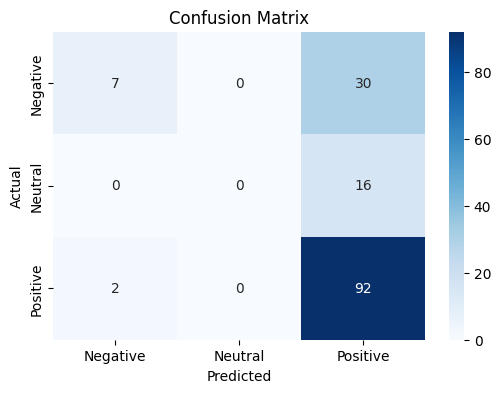

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = data['cleaned_text']
y = data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


DATA MINING:(WORD ASSOCIATION & FREQUENCY)

Top 20 Most Frequent Words:
new: 43
life: 38
day: 29
joy: 28
dream: 28
feeling: 27
moment: 27
like: 27
friend: 26
heart: 26
laughter: 24
night: 23
world: 22
art: 21
challenge: 21
echo: 21
time: 20
beauty: 20
journey: 20
emotion: 20


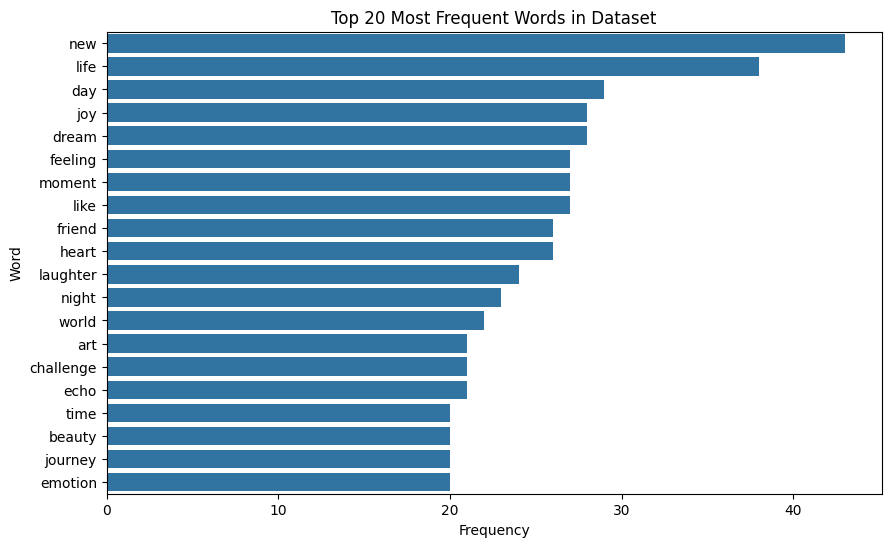


Top 20 Words Associated with Positive Sentiment:
new: 29
joy: 27
friend: 24
laughter: 24
life: 23
beauty: 20
heart: 20
challenge: 19
moment: 19
dream: 19
feeling: 17
nature: 16
sky: 16
like: 16
art: 16
adventure: 14
excitement: 14
time: 14
creativity: 14
surprise: 13


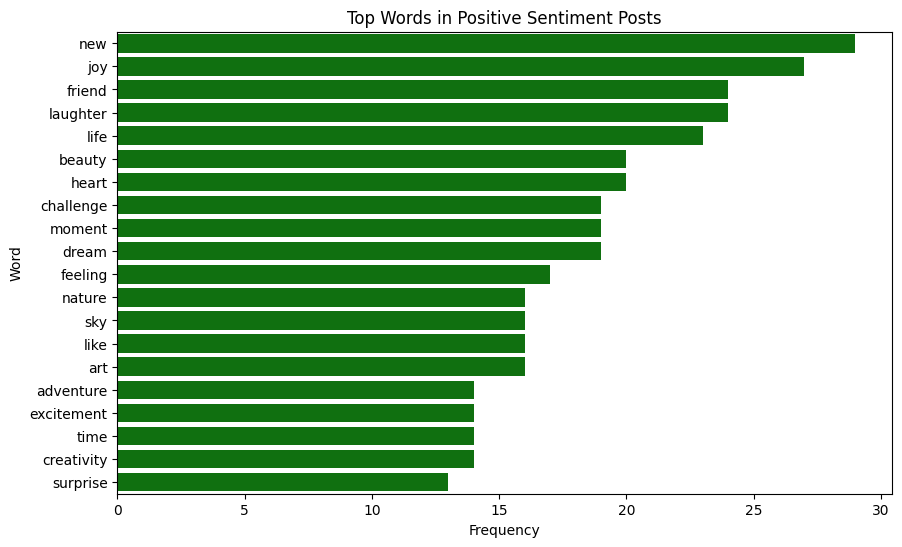

In [22]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
all_words = " ".join(data['cleaned_text']).split()
word_counts = Counter(all_words)
common_words = word_counts.most_common(20)
print("Top 20 Most Frequent Words:")
for word, freq in common_words:
    print(f"{word}: {freq}")
common_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
plt.figure(figsize=(10,6))
sns.barplot(x='Frequency', y='Word', data=common_df)
plt.title("Top 20 Most Frequent Words in Dataset")
plt.show()
positive_text = data[data['sentiment'] == 'Positive']['cleaned_text']
positive_words = " ".join(positive_text).split()
positive_counts = Counter(positive_words).most_common(20)
print("\nTop 20 Words Associated with Positive Sentiment:")
for word, freq in positive_counts:
    print(f"{word}: {freq}")
positive_df = pd.DataFrame(positive_counts, columns=['Word', 'Frequency'])
plt.figure(figsize=(10,6))
sns.barplot(x='Frequency', y='Word', data=positive_df, color='green')
plt.title("Top Words in Positive Sentiment Posts")
plt.show()


DATA VISUALIZATION

/tmp/ipython-input-2365354971.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=data, palette='viridis')


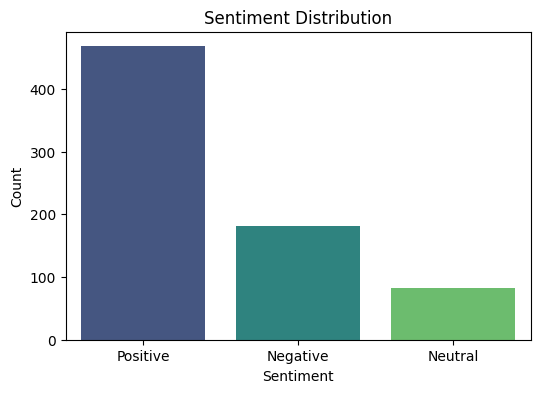

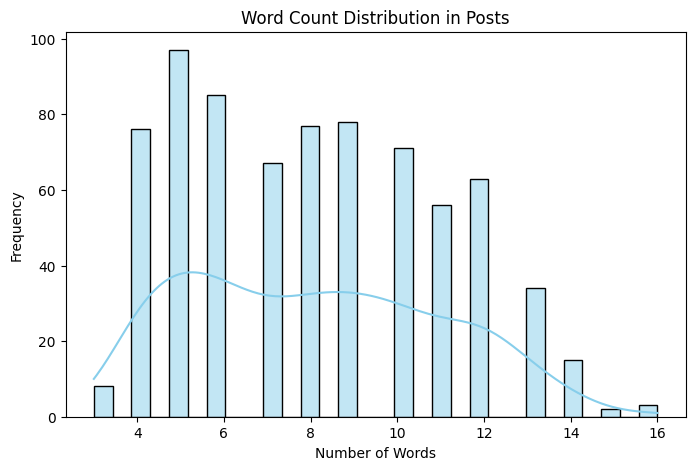

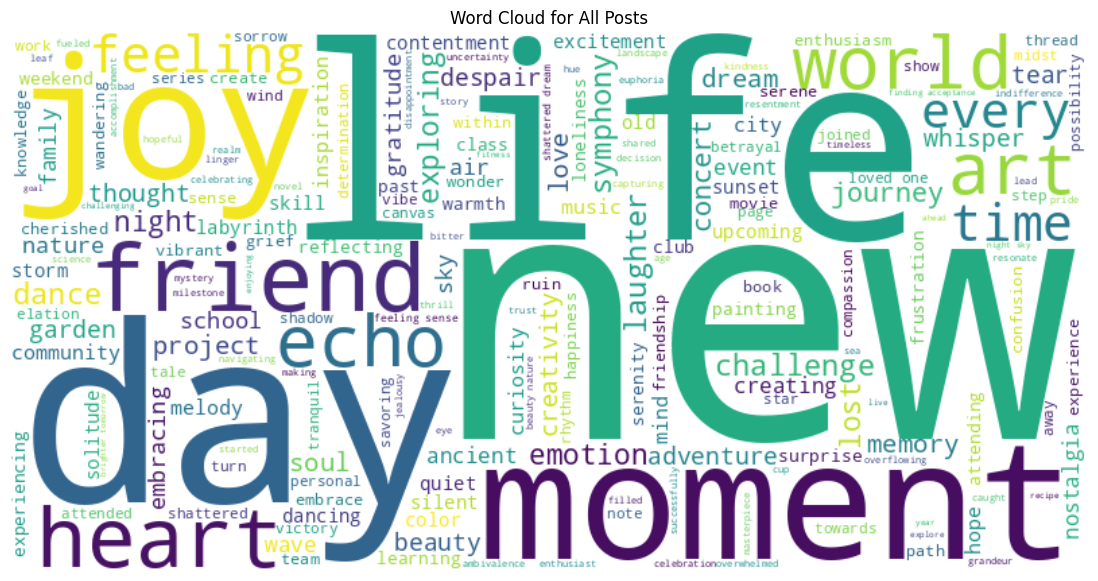

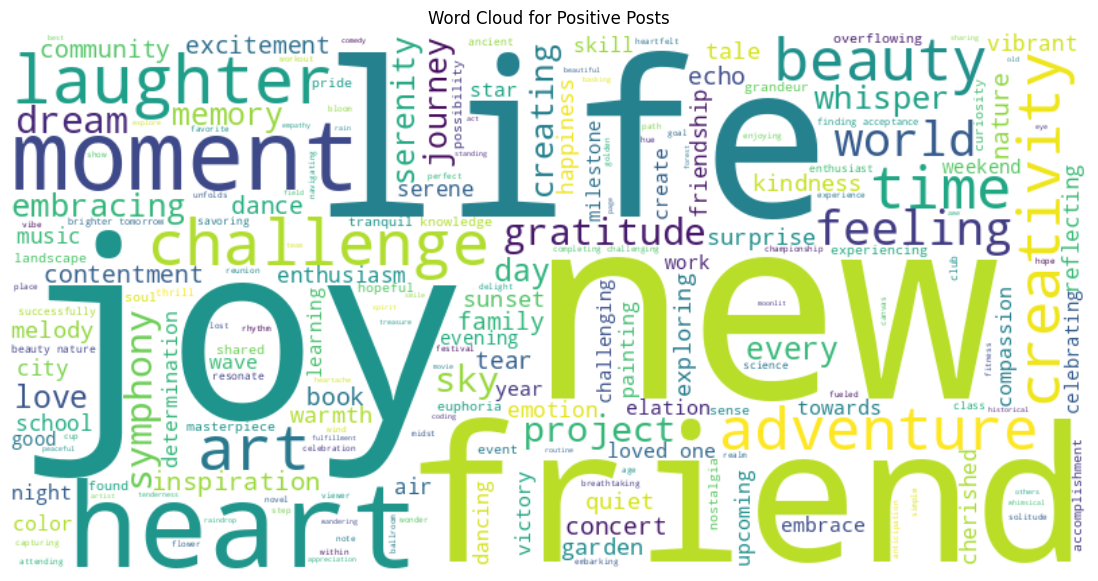

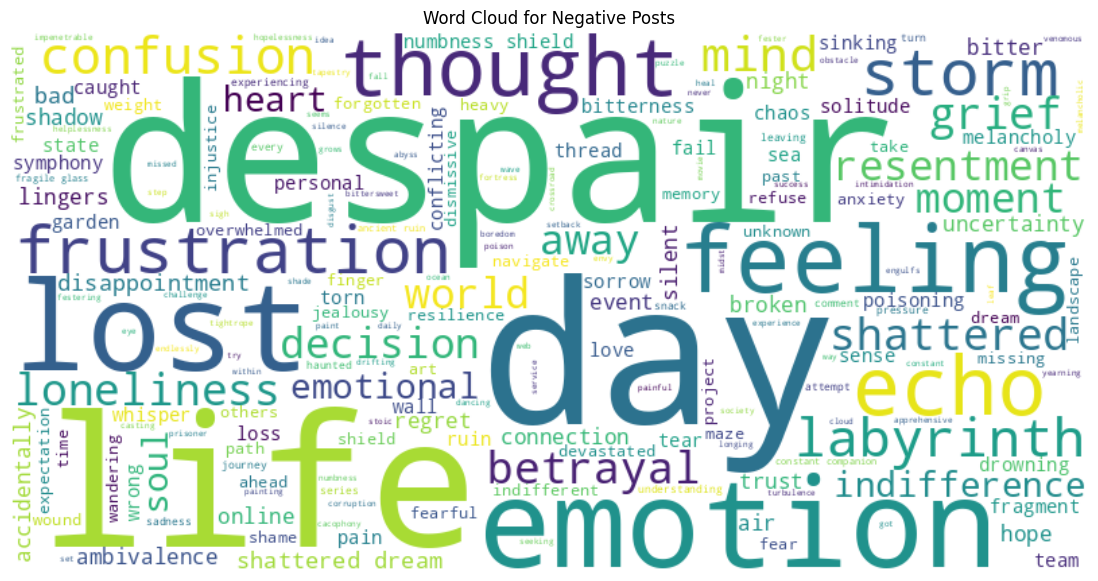

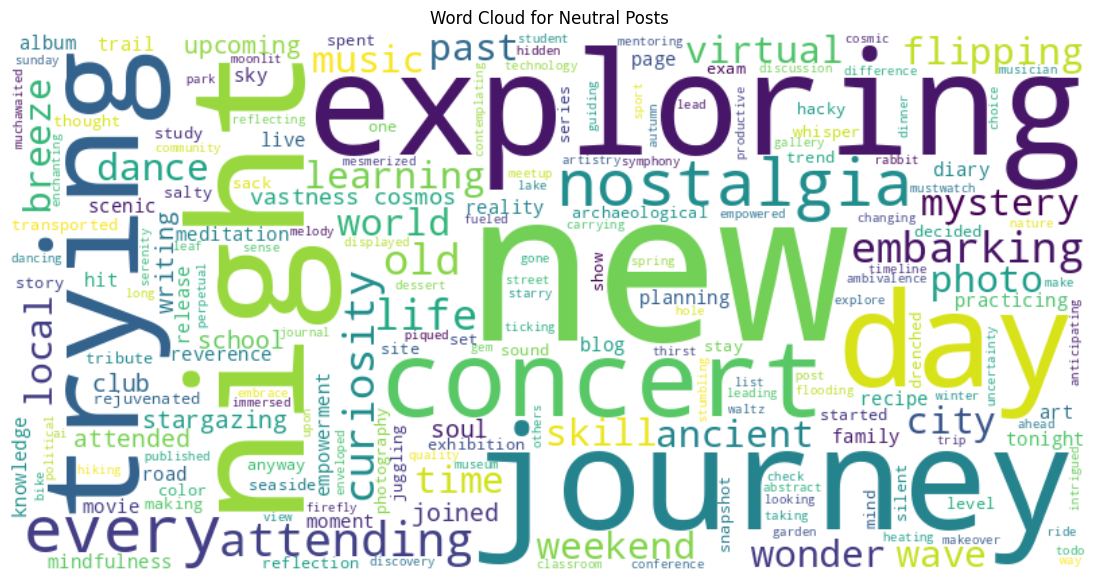

/tmp/ipython-input-2365354971.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sentiment', y='word_count', data=avg_word_count, palette='pastel')


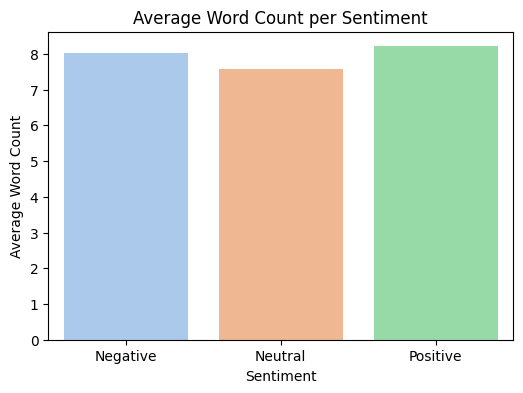

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=data, palette='viridis')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()
data['word_count'] = data['cleaned_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8,5))
sns.histplot(data['word_count'], bins=30, kde=True, color='skyblue')
plt.title("Word Count Distribution in Posts")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()
all_words = " ".join(data['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for All Posts")
plt.show()
for sentiment in data['sentiment'].unique():
    text = " ".join(data[data['sentiment'] == sentiment]['cleaned_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(15,7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {sentiment} Posts")
    plt.show()
avg_word_count = data.groupby('sentiment')['word_count'].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x='sentiment', y='word_count', data=avg_word_count, palette='pastel')
plt.title("Average Word Count per Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Word Count")
plt.show()
